# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Reproducibility for fairer model comparison.
tf.keras.utils.set_random_seed(42)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)
print("Number of classes:", len(class_names))


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 111s 1us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)
Number of classes: 10


## 🖼️ Visualize Sample Images

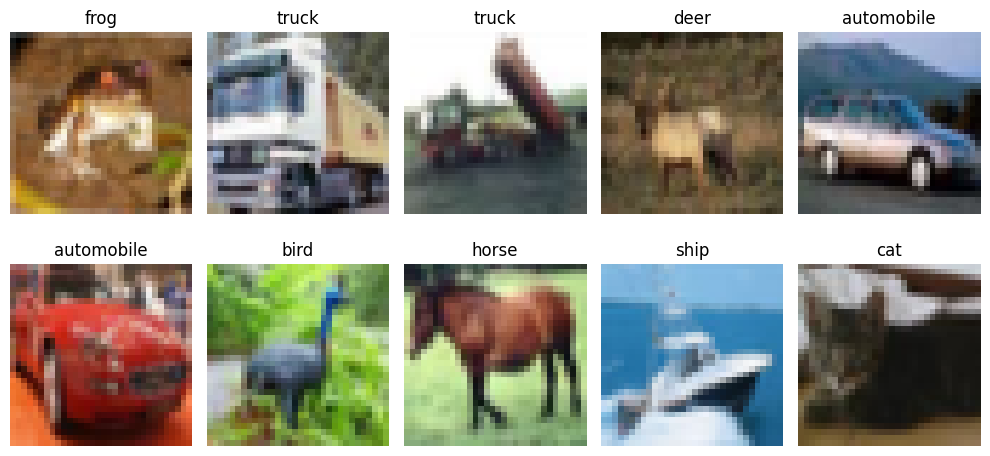

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

print("Flattened ANN input shape:", x_train_flat.shape)
print("CNN input shape:", x_train_norm.shape)


Flattened ANN input shape: (50000, 3072)
CNN input shape: (50000, 32, 32, 3)


# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[
        callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )
    ],
    verbose=1
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.2546 - loss: 2.0226 - val_accuracy: 0.3222 - val_loss: 1.8521
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.2963 - loss: 1.9071 - val_accuracy: 0.3264 - val_loss: 1.8327
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.3186 - loss: 1.8553 - val_accuracy: 0.3444 - val_loss: 1.8179
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 24ms/step - accuracy: 0.3265 - loss: 1.8352 - val_accuracy: 0.3374 - val_loss: 1.8118
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.3416 - loss: 1.8053 - val_accuracy: 0.3900 - val_loss: 1.7500
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.3422 - loss: 1.7967 - val_accuracy: 0.3774 - val_loss: 1.7430
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.3554 - loss: 1.7728 - val_accuracy: 0.3632 - val_loss: 1.7627
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.3614 - loss: 1.7601 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4326 - loss: 1.6345
ANN Test Accuracy: 0.4325999915599823


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [8]:
cnn_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[
        callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )
    ],
    verbose=1
)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,706 (1.36 MB)

 Trainable params: 357,258 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 86ms/step - accuracy: 0.4385 - loss: 1.5740 - val_accuracy: 0.5230 - val_loss: 1.2812
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 92ms/step - accuracy: 0.5840 - loss: 1.1808 - val_accuracy: 0.6106 - val_loss: 1.0878
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 86ms/step - accuracy: 0.6524 - loss: 0.9939 - val_accuracy: 0.6668 - val_loss: 0.9608
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 86ms/step - accuracy: 0.7025 - loss: 0.8569 - val_accuracy: 0.5978 - val_loss: 1.2796
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 89ms/step - accuracy: 0.7304 - loss: 0.7690 - val_accuracy: 0.7020 - val_loss: 0.8837
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 61s 86ms/step - accuracy: 0.7609 - loss: 0.6821 - val_accuracy: 0.7016 - val_loss: 0.9130
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 61s 87ms/step - accuracy: 0.7835 - loss: 0.6152 - val_accuracy: 0.7430 - val_loss: 0.8033
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 86ms/step - accuracy: 0.8055 - loss: 0.5450 - 

In [9]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7295 - loss: 0.8519
CNN Test Accuracy: 0.7294999957084656


## 📈 Compare Learning Curves

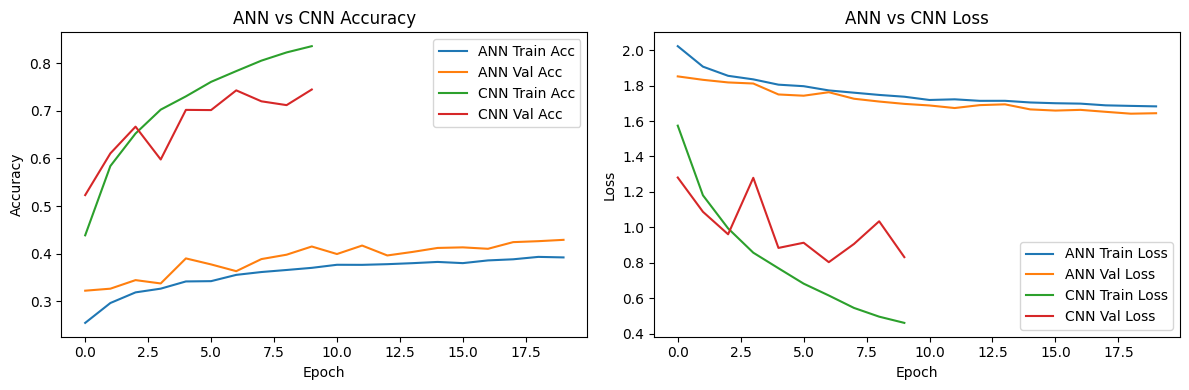

In [10]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(ann_history.history['accuracy'], label='ANN Train Acc')
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['accuracy'], label='CNN Train Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(ann_history.history['loss'], label='ANN Train Loss')
plt.plot(ann_history.history['val_loss'], label='ANN Val Loss')
plt.plot(cnn_history.history['loss'], label='CNN Train Loss')
plt.plot(cnn_history.history['val_loss'], label='CNN Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ANN vs CNN Loss")
plt.legend()

plt.tight_layout()
plt.show()


# Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

aug_cnn_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,

    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_cnn_model.summary()

aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[
        callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )
    ],
    verbose=1
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print("Augmented CNN Test Accuracy:", aug_test_acc)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,706 (1.36 MB)

 Trainable params: 357,258 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 69s 90ms/step - accuracy: 0.3907 - loss: 1.6985 - val_accuracy: 0.4166 - val_loss: 1.5467
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 62s 88ms/step - accuracy: 0.4827 - loss: 1.4322 - val_accuracy: 0.5416 - val_loss: 1.3553
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 64s 90ms/step - accuracy: 0.5352 - loss: 1.3005 - val_accuracy: 0.5738 - val_loss: 1.2338
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 62s 88ms/step - accuracy: 0.5723 - loss: 1.2198 - val_accuracy: 0.6360 - val_loss: 1.0668
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 94ms/step - accuracy: 0.6002 - loss: 1.1450 - val_accuracy: 0.6552 - val_loss: 0.9973
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 67s 95ms/step - accuracy: 0.6191 - loss: 1.0989 - val_accuracy: 0.6544 - val_loss: 1.0454
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 93ms/step - accuracy: 0.6354 - loss: 1.0506 - val_accuracy: 0.6626 - val_loss: 1.0599
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 67s 95ms/step - accuracy: 0.6490 - loss: 1.0055 - 

# 📊 Final Comparison Table

In [12]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "Augmented CNN"],
    "Test Loss": [ann_test_loss, cnn_test_loss, aug_test_loss],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, aug_test_acc],
    "Best Validation Accuracy": [
        max(ann_history.history['val_accuracy']),
        max(cnn_history.history['val_accuracy']),
        max(aug_history.history['val_accuracy'])
    ],
    "Epochs Run": [
        len(ann_history.history['loss']),
        len(cnn_history.history['loss']),
        len(aug_history.history['loss'])
    ]
})

comparison = comparison.sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
comparison


,Model,Test Loss,Test Accuracy,Best Validation Accuracy,Epochs Run
0,CNN,0.851895,0.7295,0.7448,10
1,Augmented CNN,1.030332,0.6452,0.6686,8
2,ANN,1.634501,0.4326,0.4290,20


## Compare All Three Models
The augmented CNN may train a little more slowly, but it usually generalizes better because it sees varied versions of the same images.


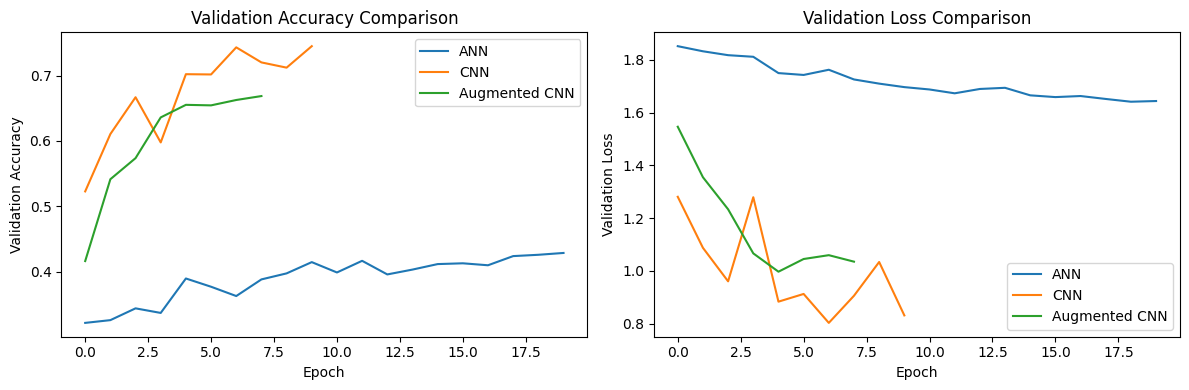

In [13]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(ann_history.history['val_accuracy'], label='ANN')
plt.plot(cnn_history.history['val_accuracy'], label='CNN')
plt.plot(aug_history.history['val_accuracy'], label='Augmented CNN')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()

plt.subplot(1,2,2)
plt.plot(ann_history.history['val_loss'], label='ANN')
plt.plot(cnn_history.history['val_loss'], label='CNN')
plt.plot(aug_history.history['val_loss'], label='Augmented CNN')
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()

plt.tight_layout()
plt.show()


## Confusion Matrix for the Best Model
This shows which classes are most often confused with each other.


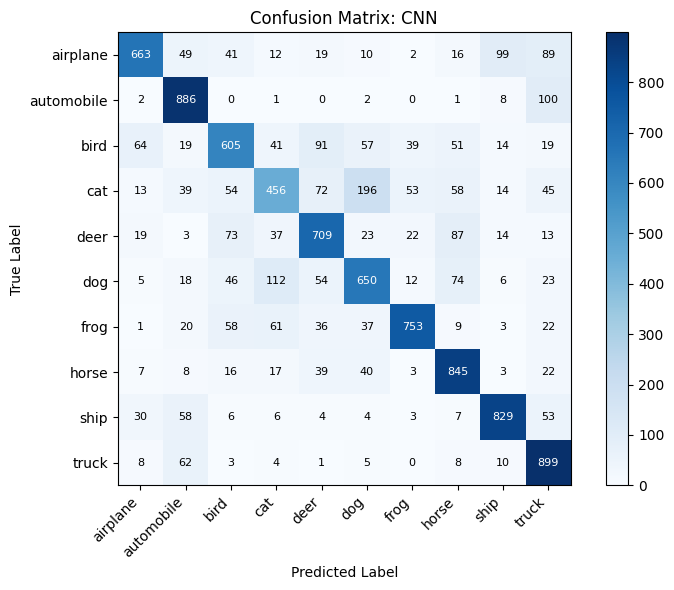

In [14]:
models_by_name = {
    "ANN": (ann_model, x_test_flat),
    "CNN": (cnn_model, x_test_norm),
    "Augmented CNN": (aug_cnn_model, x_test_norm)
}

best_model_name = comparison.loc[0, "Model"]
best_model, best_x_test = models_by_name[best_model_name]

pred_probs = best_model.predict(best_x_test, verbose=0)
y_pred = np.argmax(pred_probs, axis=1)
y_true = y_test.reshape(-1)

cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=10).numpy()

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap='Blues')
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(10), class_names, rotation=45, ha='right')
plt.yticks(range(10), class_names)
plt.colorbar()

for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=8,
                 color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.tight_layout()
plt.show()


## Prediction Examples
Green titles are correct predictions and red titles are mistakes.


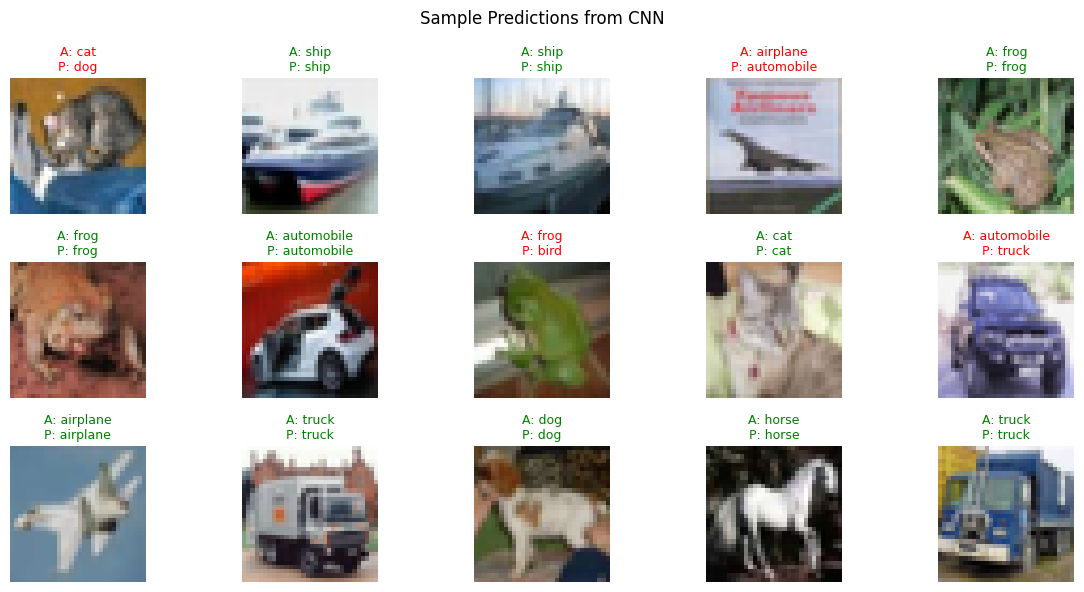

In [15]:
plt.figure(figsize=(12,6))
for i in range(15):
    plt.subplot(3,5,i+1)
    plt.imshow(x_test[i])
    actual = class_names[y_true[i]]
    predicted = class_names[y_pred[i]]
    color = 'green' if actual == predicted else 'red'
    plt.title(f"A: {actual}\nP: {predicted}", color=color, fontsize=9)
    plt.axis("off")
plt.suptitle(f"Sample Predictions from {best_model_name}")
plt.tight_layout()
plt.show()


##  Save Results
The table is saved so it can be submitted or reused in a report.


In [16]:
os.makedirs("outputs", exist_ok=True)
comparison.to_csv("outputs/cifar10_ann_cnn_comparison.csv", index=False)
print("Saved: outputs/cifar10_ann_cnn_comparison.csv")


Saved: outputs/cifar10_ann_cnn_comparison.csv


# Student Learning Tasks Completed

### Implemented in this notebook
1. Increased ANN depth and added dropout
2. Used progressive CNN filters: 32 ? 64 ? 128
3. Increased training limit to 20 epochs
4. Added **EarlyStopping** with best-weight restoration
5. Added and trained a **data augmentation CNN**
6. Compared all models using test accuracy, test loss, validation curves, confusion matrix, and sample predictions


# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**